Inputs shape: (30, 6)
Outputs shape: (30,)
First 20 rows of raw data:
    hype-para-1  hype-para-2  hype-para-3  hype-para-4  hype-para-5  hype-para-6     score source
6      0.057896     0.491672     0.247422     0.218118     0.420428     0.730970  1.364968   file
24     0.881647     0.204450     0.414474     0.420385     0.264915     0.730660  0.675142   file
14     0.148647     0.033943     0.728806     0.316066     0.021769     0.516918  0.611526   file
0      0.272624     0.324495     0.897109     0.832951     0.154063     0.795864  0.604433   file
1      0.543003     0.924694     0.341567     0.646486     0.718440     0.343133  0.562753   file
25     0.066611     0.528045     0.816095     0.961017     0.086509     0.777788  0.516457   file
23     0.175978     0.624416     0.295542     0.469553     0.097770     0.728141  0.475396   file
16     0.417626     0.064100     0.245669     0.559041     0.191531     0.254641  0.274893   file
4      0.630218     0.838097     0.680013     0.

/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/models/SurrogateNN.py:117: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  "std": param.data.std().item()


Epoch 1/500, Train Loss: 1.113464, Val Loss: 0.971871
Epoch 50/500, Train Loss: 0.341077, Val Loss: 0.498153
Early stopping at epoch 85, best val_loss=0.444486


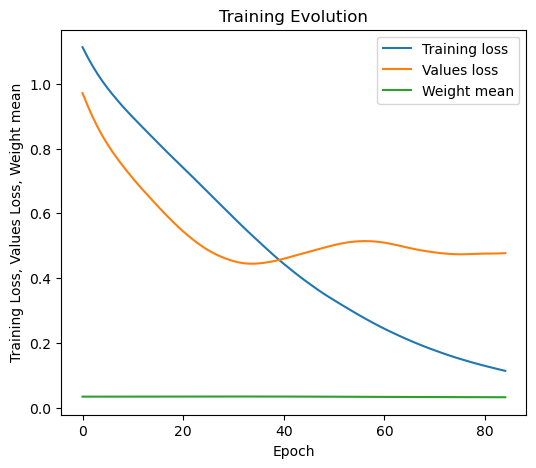

Using 6 dimensions, grid size per axis: 100, downsample: True, stride: 8
Points before downsampling: 1000000000000
Points after downsampling: 4826809
Final grid shape: (4826809, 6)
Filtered 1275210 candidates near decision boundary (|margin| < 0.2)
Excluded 3551599 candidates from consideration
Final grid shape after filtering: (1275210, 6)
Predictions range (scaled): -1.4061 to 1.2267
Inverse-transforming predictions to raw units
Predictions range (raw): -0.2052 to 0.5902
Total number of points to evaluate: 6
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.01      , 0.9939456 , 0.99382595, 0.01      , 0.01      ,
       1.01946804]), 'score': 0.004097157259132797, 'dim': 6, 'predicted_y': 0.5871629}
{'method': 'PI', 'xi': 0.1, 'kappa': None, 'x': array([0.01      , 0.9939456 , 0.99382595, 0.01      , 0.01      ,
       1.01946804]), 'score': 0.0031092658760516543, 'dim': 6, 'predicted_y': 0.5871629}
{'method': 'EI', 'xi': 0.01, 'kappa': None, 'x': array([0.01      , 0.993945

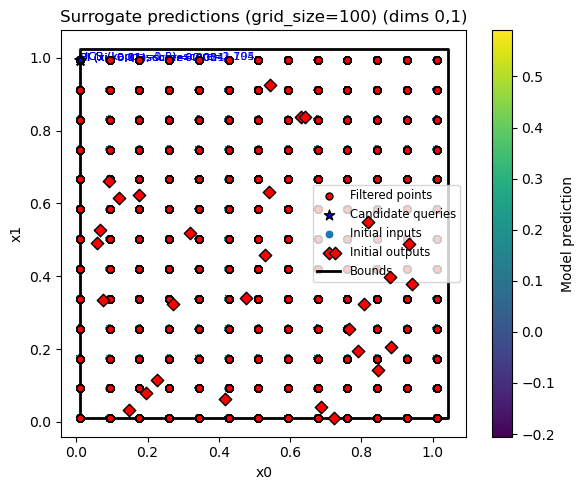

<Figure size 600x500 with 0 Axes>

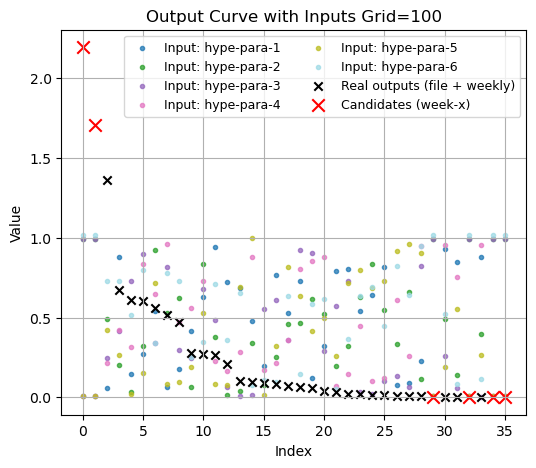

Saved dataframe to: results/run_2025-12-11 19-40-31/df_grid_100_stride8_median_max_raw_lr0.001_ep600.csv
Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 1.0, 'x': array([0.01      , 0.9939456 , 0.99382595, 0.01      , 0.01      ,
       1.01946804]), 'score': 2.194031364649723, 'dim': 6, 'predicted_y': 0.5871629}
    hype-para-1  hype-para-2  hype-para-3  hype-para-4  hype-para-5  hype-para-6     score  source  score-scaled
0      0.010000     0.993946     0.993826     0.010000     0.010000     1.019468  2.194031  week-x     10.000000
1      0.010000     0.993946     0.993826     0.010000     0.010000     1.019468  1.705292  week-x      7.772414
2      0.057896     0.491672     0.247422     0.218118     0.420428     0.730970  1.364968    file      6.221280
3      0.881647     0.204450     0.414474     0.420385     0.264915     0.730660  0.675142    file      3.077174
4      0.148647     0.033943     0.728806     0.316066     0.021769     0.516918  0.611526    file      2.787223


In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (6, 5)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh)

print("Pipeline finished. Results keys:", list(results.keys()))